Saving sorted_dataset.zip to sorted_dataset (2).zip
Found 1778 images belonging to 2 classes.
Found 443 images belonging to 2 classes.
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.5672 - loss: 0.9895 - val_accuracy: 0.6027 - val_loss: 0.6699
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.6457 - loss: 0.6484 - val_accuracy: 0.5779 - val_loss: 0.6998
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.5786 - loss: 0.6460 - val_accuracy: 0.6230 - val_loss: 0.8437
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.6550 - loss: 0.6411 - val_accuracy: 0.5982 - val_loss: 0.7809


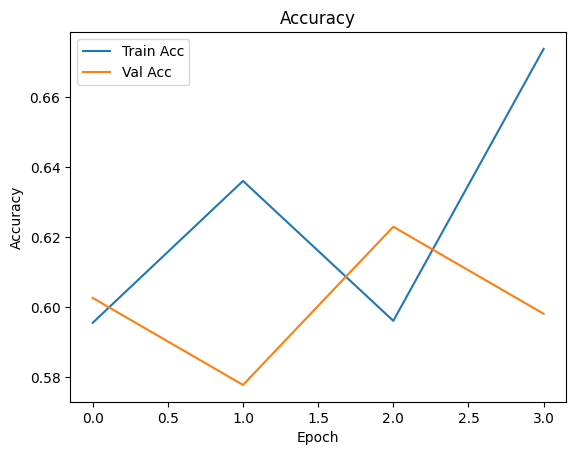

In [ ]:
# =========================
# 0. Libraries & install
# =========================
!pip install tensorflow matplotlib scikit-learn --quiet

# =========================
# 1. Upload + unzip dataset
# =========================
from google.colab import files
uploaded = files.upload()                       # sélectionne ton .zip

import zipfile
from pathlib import Path

zip_path = next(iter(uploaded))                 # prend le premier fichier chargé
extract_dir = Path("dataset")
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_dir)

# =========================
# 2. Data generators
# =========================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

# data augmentation + split
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,          # 20 % pour la validation
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    extract_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = val_datagen.flow_from_directory(
    extract_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# =========================
# 3. CNN model + Dropout
# =========================
from tensorflow.keras import layers, models, Input

inputs = Input(shape=(128, 128, 3))
x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
x = layers.MaxPooling2D(2, 2)(x)
x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D(2, 2)(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)                             # <-- Dropout ajouté
outputs = layers.Dense(train_gen.num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# =========================
# 4. EarlyStopping callback
# =========================
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,                 # stoppe après 3 epochs sans amélioration
    restore_best_weights=True
)

# =========================
# 5. Training
# =========================
history = model.fit(
    train_gen,
    epochs=20,                  # mets plus haut si tu veux ; EarlyStopping gère l’arrêt
    validation_data=val_gen,
    callbacks=[early_stop],
    verbose=1
)

# =========================
# 6. Visualiser l’apprentissage
# =========================
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# =========================
# 7. Feature extractor (facultatif pour détection d’anomalies)
# =========================
feature_extractor = models.Model(inputs=model.input, outputs=model.layers[-2].output)


Saving My Chicken Looks Sick! Now What_.jpeg to My Chicken Looks Sick! Now What_.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Image: My Chicken Looks Sick! Now What_.jpeg
Prédit comme: sick avec une probabilité de 0.87


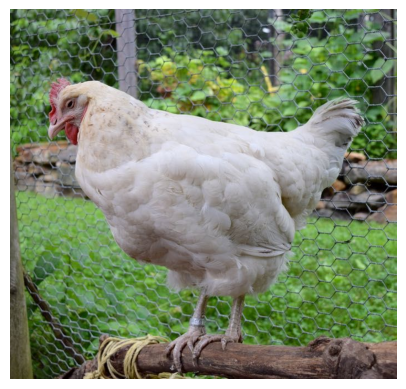

In [ ]:
from google.colab import files
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# upload image
uploaded = files.upload()

# get the uploaded image path (prend la première image uploadée)
test_image_path = next(iter(uploaded.keys()))

# Exemple de mapping classes (à adapter selon tes classes)
class_indices = {'healthy': 0, 'sick': 1, 'other': 2}

# Fonction pour préparer l'image
def prepare_image(img_path, img_size=(128, 128)):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0  # Normalisation
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# Fonction pour prédire et afficher
def predict_image(model, img_path, class_indices):
    img_prepared = prepare_image(img_path)
    preds = model.predict(img_prepared)
    pred_class_index = np.argmax(preds)

    # inverser le dictionnaire pour récupérer la classe
    index_to_class = {v: k for k, v in class_indices.items()}
    pred_class_label = index_to_class[pred_class_index]

    pred_prob = preds[0][pred_class_index]

    print(f"Image: {img_path}")
    print(f"Prédit comme: {pred_class_label} avec une probabilité de {pred_prob:.2f}")

    img = image.load_img(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Appeler la fonction avec l'image uploadée
predict_image(model, test_image_path, class_indices)


Saving Healthy and Sick Chicken Detection.v20i.tensorflow.zip to Healthy and Sick Chicken Detection.v20i.tensorflow.zip
Found 2397 images belonging to 3 classes.
Found 598 images belonging to 3 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 69s 837ms/step - accuracy: 0.7999 - loss: 0.8274 - val_accuracy: 0.8645 - val_loss: 0.3758
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 53s 701ms/step - accuracy: 0.8804 - loss: 0.3456 - val_accuracy: 0.8679 - val_loss: 0.3758
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 52s 696ms/step - accuracy: 0.8743 - loss: 0.3323 - val_accuracy: 0.8629 - val_loss: 0.3344
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 50s 672ms/step - accuracy: 0.8935 - loss: 0.2781 - val_accuracy: 0.8662 - val_loss: 0.3447
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 51s 669ms/step - accuracy: 0.8972 - loss: 0.2596 - val_accuracy: 0.8545 - val_loss: 0.3332
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 54s 715ms/step - accuracy: 0.8988 - loss: 0.2536 - val_accuracy: 0.8662 - val_loss: 0.3484
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 52s 699ms/step - accuracy: 0.9082 - loss: 0.2342 - val_accuracy: 0.8746 - val_loss: 0.3463
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 81s 688ms/step - accuracy: 0.9009 - loss: 0.2629 - val_accu

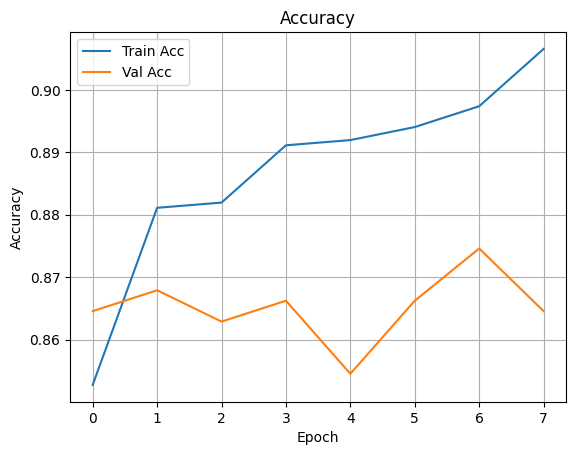

NameError: name 'tf' is not defined

In [ ]:
# =========================
# 0. Installer les librairies nécessaires (si ce n'est pas fait)
# =========================
!pip install tensorflow matplotlib scikit-learn --quiet
# =========================
# 1. Upload et extraction du dataset
# =========================
from google.colab import files
import zipfile
from pathlib import Path

uploaded = files.upload()  # uploader ton .zip

zip_path = next(iter(uploaded))  # on prend le nom du fichier chargé
extract_dir = Path("dataset")

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_dir)
# =========================
# 2. Data generators avec preprocessing MobileNetV2
# =========================
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    extract_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = val_datagen.flow_from_directory(
    extract_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)
# =========================
# 3. Création du modèle avec MobileNetV2 (Transfer Learning)
# =========================
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, Input

base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # on freeze les poids pré-entraînés

inputs = Input(shape=(128, 128, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(train_gen.num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
# =========================
# 4. Entraînement avec EarlyStopping
# =========================
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=[early_stop],
    verbose=1
)
# =========================
# 5. Visualisation de l'apprentissage
# =========================
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
# =========================
# 6. (Optionnel) Fine-tuning de MobileNetV2
# =========================
base_model.trainable = True  # défreeze MobileNet

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# On réentraine quelques epochs pour ajuster aux données
history_ft = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[early_stop],
    verbose=1
)


In [ ]:
# Sauvegarde du modèle complet
model.save("chicken_disease_model.h5")


In [ ]:
from google.colab import files
files.download("chicken_disease_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# 🐔 Charge l'image à tester (upload d'abord)
uploaded = files.upload()  # sélectionne une image jpg/png

# Nom du fichier chargé
img_path = next(iter(uploaded))

# 🔄 Prétraitement (resize + normalisation)
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # même normalisation que pendant l'entraînement
img_array = np.expand_dims(img_array, axis=0)  # batch de taille 1

# 🔍 Prédiction
pred = model.predict(img_array)
class_idx = np.argmax(pred)
class_labels = list(train_gen.class_indices.keys())

print(f"🧠 Prédiction : {class_labels[class_idx]} (confiance : {pred[0][class_idx]:.2f})")


Saving My Chicken Looks Sick! Now What_.jpeg to My Chicken Looks Sick! Now What_.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
🧠 Prédiction : train (confiance : 0.82)


Saving sorted_dataset.zip to sorted_dataset.zip
✅ Dataset extrait dans : /content/sorted_dataset
Found 1778 images belonging to 2 classes.
Found 443 images belonging to 2 classes.
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.5445 - loss: 1.3771 - val_accuracy: 0.5779 - val_loss: 0.6682
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.6133 - loss: 0.6484 - val_accuracy: 0.6275 - val_loss: 0.6465
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.6602 - loss: 0.6369 - val_accuracy: 0.6546 - val_loss: 0.6461
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.6683 - loss: 0.6342 - val_accuracy: 0.5937 - val_loss: 0.6786
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.6798 - loss: 0.6227 - val_accuracy: 0.6253 - val_loss: 0.7118
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.6607 - loss: 0.6279 - val_accuracy: 0.6321 - val_loss: 0.7532


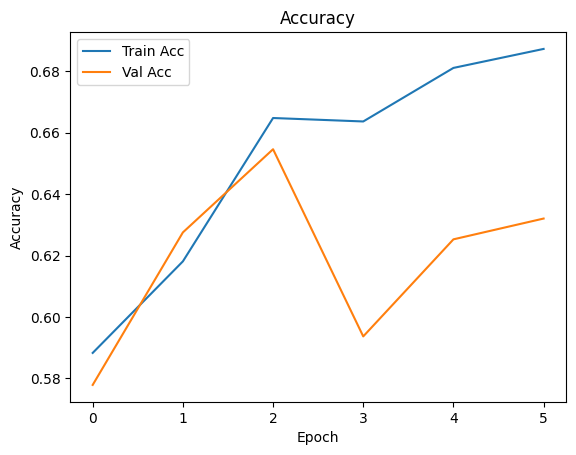

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 1. LIBRAIRIES POUR L'UPLOAD ET EXTRACTION
from google.colab import files
import zipfile
import shutil
from pathlib import Path

# 2. UPLOAD
uploaded = files.upload()  # Sélectionne ton .zip contenant les dossiers healthy/ et sick/

# 3. EXTRACTION
zip_path = next(iter(uploaded))
extract_dir = Path("/content/sorted_dataset")

if extract_dir.exists():
    shutil.rmtree(extract_dir)

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_dir)

print("✅ Dataset extrait dans : /content/sorted_dataset")
# 4. LIBRAIRIES POUR LE MODELE
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 5. PARAMÈTRES
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
DATASET_DIR = "/content/sorted_dataset"

# 6. GENERATEURS D’IMAGES
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# 7. MODELE CNN SIMPLE AVEC DROPOUT
inputs = Input(shape=(128, 128, 3))
x = layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = layers.MaxPooling2D(2,2)(x)
x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D(2,2)(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(train_gen.num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 8. ENTRAÎNEMENT + EARLY STOPPING
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)

# 9. COURBES D’APPRENTISSAGE
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
# 10. SAUVEGARDE DU MODELE
model.save("chicken_cnn_model.h5")



✅ Dataset extrait dans : /content/sorted_dataset
Found 1778 images belonging to 2 classes.
Found 443 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 46s 710ms/step - accuracy: 0.6606 - loss: 0.7175 - val_accuracy: 0.6930 - val_loss: 0.7622
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 40s 715ms/step - accuracy: 0.7593 - loss: 0.4995 - val_accuracy: 0.6862 - val_loss: 0.9942
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 43s 772ms/step - accuracy: 0.8034 - loss: 0.4287 - val_accuracy: 0.6953 - val_loss: 1.0072
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 74s 625ms/step - accuracy: 0.8234 - loss: 0.3986 - val_accuracy: 0.6885 - val_loss: 1.0558
Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.6781 - loss: 0.6464 - val_accuracy: 0.7065 - val_loss: 0.8131
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.7423 - loss: 0.5355 - val_accuracy: 0.7133 - val_loss: 0.8463
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.7591 - loss: 0.4899 - val_accuracy: 0.7201 - val_loss: 0.8396
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.7754 - loss: 0.4617 - val_accuracy: 0.

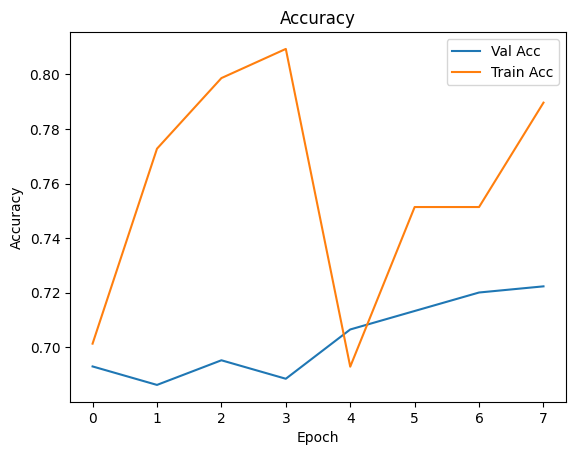

✅ Modèle sauvegardé : mobilenetv2_chickens.h5


In [ ]:
# 0. Install & Import
!pip install tensorflow --quiet

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import zipfile, shutil
from pathlib import Path
import os

# 1. Unzip le dataset
zip_path = "/content/sorted_dataset.zip"
extract_dir = Path("/content/sorted_dataset")
if extract_dir.exists():
    shutil.rmtree(extract_dir)

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_dir)

print("✅ Dataset extrait dans :", extract_dir)

# 2. Data generators
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    extract_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = val_datagen.flow_from_directory(
    extract_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# 3. MobileNetV2 base model
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # freeze pour le début

# 4. Model architecture
inputs = Input(shape=(128, 128, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(train_gen.num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 5. Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 6. Train
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stop]
)

# 7. Fine-tuning (débloquer quelques couches de MobileNet)
base_model.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),  # très petit learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop]
)

# 8. Courbes de performance
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'], label='Val Acc')
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'], label='Train Acc')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 9. Sauvegarde du modèle
model.save("mobilenetv2_chickens.h5")
print("✅ Modèle sauvegardé : mobilenetv2_chickens.h5")


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
from tensorflow.keras.models import load_model

# Charger le modèle
model = load_model('mobilenet_chicken_classifier.h5')  # Remplace avec ton chemin réel

# Charger l'image avec la bonne taille
img_path = '/content/photo_2025-06-01_13-18-27.jpg'  # Remplace avec le vrai chemin
img = image.load_img(img_path, target_size=(128, 128))  # 👈 ton modèle attend 128x128

# Préparation
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Prédiction
prediction = model.predict(img_array)

# Affichage du résultat (0 = saine, 1 = malade par exemple)
if prediction[0][0] > 0.5:
    print("🟥 Classe prédite : Malade")
else:
    print("🟩 Classe prédite : Saine")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
🟥 Classe prédite : Malade
